# Classical MPNNs vs NSD

This notebook plots the graph-transfer and signal-propagation experiments for the Python 3.13 branch. Set the W&B entity/project names below, then run the cells after launching the scripts in `exp/scripts/`.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import wandb

sns.set_theme(style="whitegrid", context="notebook")

ENTITY = None  # e.g. "your-wandb-entity"; leave None for default
TRANSFER_PROJECT = "on-oversquashing-transfer"
TRANSFER_GROUP = "graph-transfer-classical-vs-nsd"
SIGNAL_CSV = Path("../signal_propagation_results/NCI1_signal_propagation.csv")
FIG_DIR = Path("../notebooks/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
def wandb_path(project, entity=None):
    return f"{entity}/{project}" if entity else project


def load_transfer_runs(project=TRANSFER_PROJECT, group=TRANSFER_GROUP, entity=ENTITY):
    api = wandb.Api()
    filters = {"group": group} if group else None
    rows = []
    for run in api.runs(wandb_path(project, entity), filters=filters):
        cfg = {k: v for k, v in run.config.items() if not k.startswith("_")}
        summary = run.summary._json_dict
        rows.append({
            "run_id": run.id,
            "name": run.name,
            "state": run.state,
            "model": cfg.get("model"),
            "dataset": cfg.get("dataset"),
            "topology": cfg.get("topology"),
            "synthetic_size": cfg.get("synthetic_size"),
            "mpnn_layers": cfg.get("mpnn_layers"),
            "hidden_dim": cfg.get("hidden_dim"),
            "seed": cfg.get("seed"),
            "sheaf_variant": cfg.get("sheaf_variant"),
            "best_acc": summary.get("best_acc", summary.get("best_test_acc")),
            "final_acc": summary.get("final_acc"),
            "best_epoch": summary.get("best_epoch"),
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        df["synthetic_size"] = pd.to_numeric(df["synthetic_size"])
        df["best_acc"] = pd.to_numeric(df["best_acc"])
        df["final_acc"] = pd.to_numeric(df["final_acc"])
    return df


transfer_df = load_transfer_runs()
display(transfer_df)

,run_id,name,state,model,dataset,topology,synthetic_size,mpnn_layers,hidden_dim,seed,sheaf_variant,best_acc,final_acc,best_epoch
0,lxqh69bf,misty-cherry-1,finished,gcn,RING,ring,2,1,64,1,general,38.0,38.0,4
1,8nkns66a,youthful-meadow-2,finished,gcn,RING,crossed-ring,2,1,64,1,general,38.0,38.0,4
2,0oue5yc8,earnest-mountain-3,finished,gcn,LOLLIPOP,lollipop,2,2,64,1,general,100.0,100.0,0
3,w8qw1ddz,polished-water-4,finished,gcn,TREE,tree,2,1,64,1,general,21.2,17.4,0
4,41e4u0yv,flowing-salad-5,finished,gat,RING,ring,2,1,64,1,general,38.0,38.0,4
5,4cfh5wr9,rare-planet-6,finished,gat,RING,crossed-ring,2,1,64,1,general,38.0,38.0,4
6,0kl0oabv,eternal-surf-7,finished,gat,LOLLIPOP,lollipop,2,2,64,1,general,100.0,100.0,0
7,3k8mmjt1,different-flower-8,finished,gat,TREE,tree,2,1,64,1,general,21.2,19.6,0
8,aakyq2lg,trim-field-9,finished,nsd,RING,ring,2,1,64,1,general,100.0,100.0,0
9,zh62hfv9,swept-water-10,finished,nsd,RING,crossed-ring,2,1,64,1,general,100.0,100.0,0


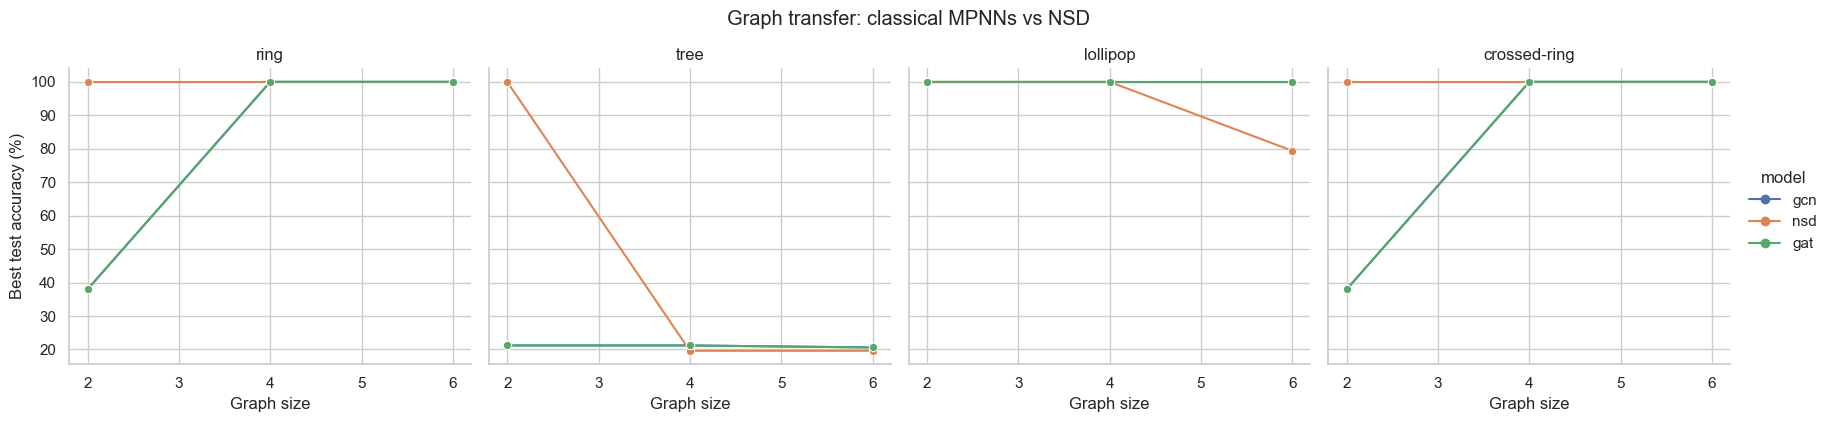

In [8]:
if transfer_df.empty:
    print("No W&B transfer runs found yet. Run exp/scripts/run_graph_transfer_comparison.sh first.")
else:
    g = sns.relplot(
        data=transfer_df.sort_values("synthetic_size"),
        x="synthetic_size",
        y="best_acc",
        hue="model",
        col="topology",
        kind="line",
        marker="o",
        errorbar="sd",
        facet_kws={"sharey": True, "sharex": True},
        height=4,
        aspect=1.1,
    )
    g.set_axis_labels("Graph size", "Best test accuracy (%)")
    g.set_titles("{col_name}")
    g.figure.suptitle("Graph transfer: classical MPNNs vs NSD", y=1.05)
    out = FIG_DIR / "graph_transfer_classical_vs_nsd.png"
    g.figure.savefig(out, dpi=200, bbox_inches="tight")
    out

In [9]:
if SIGNAL_CSV.exists():
    signal_df = pd.read_csv(SIGNAL_CSV)
else:
    signal_df = pd.DataFrame()
    print(f"No signal CSV found at {SIGNAL_CSV}. Run exp/scripts/run_signal_propagation_comparison.sh first.")

signal_df.head()

No signal CSV found at ../signal_propagation_results/NCI1_signal_propagation.csv. Run exp/scripts/run_signal_propagation_comparison.sh first.


""


In [10]:
if not signal_df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.lineplot(
        data=signal_df.sort_values("effective_resistance"),
        x="effective_resistance",
        y="propagation",
        hue="model",
        errorbar="sd",
        ax=ax,
    )
    ax.set_xlabel("Total effective resistance")
    ax.set_ylabel("Signal propagation")
    ax.set_title("Signal propagation: classical MPNNs vs NSD")
    sns.despine(fig=fig, ax=ax)
    fig.tight_layout()
    out = FIG_DIR / "signal_propagation_classical_vs_nsd.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    out